# UniProtKB Parquet Data Lake Demo

This notebook demonstrates querying the UniProtKB Parquet data lake using **DuckDB**, **Polars**, **pandas**, and **PyArrow**.

The demo dataset contains proteins from **five model organisms** (Human, Mouse, Fruit fly, Arabidopsis, Yeast) — a mix of reviewed (Swiss-Prot) and unreviewed (TrEMBL) entries, small enough to run on a laptop, large enough to show real query patterns.

### Data model

Five sorted Parquet tables, all sharing `(acc, taxid)` as join keys:

| Table | Description | Key columns |
|-------|-------------|-------------|
| **entries** | One row per protein | `acc`, `reviewed`, `taxid`, `gene_name`, `protein_name`, `sequence`, `seq_length`, ... |
| **features** | One row per positional annotation | `acc`, `type`, `start_pos`, `end_pos`, `description`, ... |
| **xrefs** | One row per cross-reference | `acc`, `database`, `id`, `properties`, ... |
| **comments** | One row per comment | `acc`, `comment_type`, `text_value`, ... |
| **publications** | One row per citation | `acc`, `citation_type`, `title`, `authors`, ... |

Each table has two layers: **flattened convenience columns** for simple SQL, and **full nested structs** for lossless access to the original UniProtKB JSON.

## 1. Setup

In [1]:
import os
import sys
import json

# Path to the demo lake (built by run_demo.sh)
LAKE = os.path.join(os.getcwd(), "lake", "2026_01", "lake")
assert os.path.exists(LAKE), f"Lake not found at {LAKE} — run ./run_demo.sh first"

# Add project root so we can import uniprot_lake.py
sys.path.insert(0, os.path.join(os.getcwd(), ".."))

# Quick inventory
with open(os.path.join(LAKE, "manifest.json")) as f:
    manifest = json.load(f)

print(f"Release: {manifest['release']}")
print(f"Total rows: {manifest['total_rows']:,}")
print()
for name, info in manifest["tables"].items():
    print(f"  {name:12s}  {info['row_count']:>10,} rows  ({len(info['files'])} files)")

Release: 2026_01
Total rows: 134,016

  entries            5,378 rows  (1 files)
  features          10,817 rows  (1 files)
  xrefs             95,385 rows  (1 files)
  comments           4,261 rows  (1 files)
  publications      18,175 rows  (1 files)


## 2. DuckDB — SQL queries with views and macros

The `uniprot_lake.connect()` one-liner sets up five views (`entries`, `features`, `xrefs`, `comments`, `publications`) and six macros. No globs or boilerplate needed.

In [2]:
from uniprot_lake import connect, schema

con = connect(LAKE)
print("Connected. Available views and macros are ready.")

Connected. Available views and macros are ready.


### Explore the schema

In [3]:
# Overview of all tables — descriptions, row counts, keys, join hints
overview = schema(LAKE)
for name, info in overview.items():
    print(f"\n{name}:")
    for k, v in info.items():
        print(f"  {k}: {v}")


entries:
  description: One row per protein. Primary table for most queries.
  row_count: 5378
  primary_key: ['acc']
  sort_order: ['reviewed DESC', 'taxid ASC', 'acc ASC']

features:
  description: One row per positional annotation (domain, signal, transmembrane, etc). Sorted by (from_reviewed DESC, taxid ASC, acc ASC) for locality; use ORDER BY start_pos for position-sorted queries within a protein.
  row_count: 10817
  primary_key: []
  sort_order: ['from_reviewed DESC', 'taxid ASC', 'acc ASC']
  foreign_keys: {'acc': 'entries.acc', 'taxid': 'entries.taxid'}
  join_hint: JOIN features USING (acc, taxid)

xrefs:
  description: One row per cross-reference to an external database (PDB, Ensembl, GO, InterPro, etc).
  row_count: 95385
  primary_key: []
  sort_order: ['from_reviewed DESC', 'taxid ASC', 'acc ASC']
  foreign_keys: {'acc': 'entries.acc', 'taxid': 'entries.taxid'}
  join_hint: JOIN xrefs USING (acc, taxid)

comments:
  description: One row per comment annotation (function, 

In [4]:
# Detailed column list for the entries table
# (Nested struct types are truncated for readability)
con.sql("""
    SELECT
        column_name,
        CASE
            WHEN length(column_type) > 40
            THEN column_type[:37] || '...'
            ELSE column_type
        END AS column_type,
        "null",
        key,
        "default",
        extra
    FROM (DESCRIBE entries)
""").df()

,column_name,column_type,null,key,default,extra
0,acc,VARCHAR,YES,None,None,None
1,id,VARCHAR,YES,None,None,None
2,reviewed,BOOLEAN,YES,None,None,None
3,secondary_accs,VARCHAR[],YES,None,None,None
4,taxid,BIGINT,YES,None,None,None
5,organism_name,VARCHAR,YES,None,None,None
6,organism_common,VARCHAR,YES,None,None,None
7,lineage,VARCHAR[],YES,None,None,None
8,gene_names,VARCHAR[],YES,None,None,None
9,gene_synonyms,VARCHAR[],YES,None,None,None


### Basic queries

In [5]:
# Top 10 proteins by sequence length
con.sql("""
    SELECT acc, gene_names, protein_name, seq_length, annotation_score
    FROM entries
    ORDER BY seq_length DESC
    LIMIT 10
""").df()

,acc,gene_names,protein_name,seq_length,annotation_score
0,O49519,[CLE2],CLAVATA3/ESR (CLE)-related protein 2,75,5.0
1,O82232,[None],PMP3 family protein At2g24040,75,1.0
2,O82275,[TAX1],Signaling peptide TAXIMIN 1,75,4.0
3,P82721,[LCR6],Putative defensin-like protein 126,75,2.0
4,P82734,[LCR20],Defensin-like protein 127,75,2.0
5,P82767,[LCR53],Putative defensin-like protein 119,75,2.0
6,Q1PEX8,[CYSTM5],Protein CYSTEINE-RICH TRANSMEMBRANE MODULE 5,75,4.0
7,Q2V2Q4,[None],Putative defensin-like protein 55,75,2.0
8,Q2V352,[None],Putative defensin-like protein 271,75,2.0
9,Q3ECL0,[RALFL9],Protein RALF-like 9,75,2.0


In [6]:
# Summary statistics
con.sql("""
    SELECT
        count(*)                          AS total_proteins,
        count(DISTINCT taxid)             AS organisms,
        round(avg(seq_length), 1)         AS avg_seq_length,
        min(seq_length)                   AS min_seq_length,
        max(seq_length)                   AS max_seq_length,
        round(avg(feature_count), 1)      AS avg_features,
        round(avg(xref_count), 1)         AS avg_xrefs,
        sum(reviewed::int)                AS reviewed_count
    FROM entries
""").df()

,total_proteins,organisms,avg_seq_length,min_seq_length,max_seq_length,avg_features,avg_xrefs,reviewed_count
0,5378,5,72.4,70,75,2.0,17.7,272.0


### Using the built-in macros

In [7]:
# Annotation card for a single protein (pick the most-annotated reviewed entry)
top_acc = con.sql("""
    SELECT acc FROM entries
    WHERE reviewed = true
    ORDER BY feature_count DESC
    LIMIT 1
""").fetchone()[0]
print(f"Showing card for {top_acc}")
con.sql(f"SELECT * FROM protein_card('{top_acc}')").df()

Showing card for Q969W0


,acc,gene_name,protein_name,organism_name,taxid,reviewed,seq_length,protein_existence,annotation_score,go_ids,keyword_names,ec_numbers,feature_count,xref_count,comment_count,reference_count
0,Q969W0,SPTSSA,Serine palmitoyltransferase small subunit A,Homo sapiens,9606,True,71,1: Evidence at protein level,5.0,"[GO:0046512, GO:0030148, GO:0008104, GO:004651...","[3D-structure, Disease variant, Endoplasmic re...",[],15,132,14,9


In [8]:
# All 'Domain' features for the most-represented organism
top_taxid = con.sql("""
    SELECT taxid FROM entries
    GROUP BY taxid ORDER BY count(*) DESC LIMIT 1
""").fetchone()[0]
print(f"Domain features for taxid {top_taxid}:")
con.sql(f"SELECT * FROM organism_features({top_taxid}, 'Domain') LIMIT 15").df()

Domain features for taxid 9606:


,acc,type,start_pos,end_pos,description,feature_id,evidence_codes
0,A0A023IP89,Domain,23,69,Integrin beta subunit cytoplasmic,None,[ECO:0000259]
1,A0A023IQH3,Domain,23,69,Integrin beta subunit cytoplasmic,None,[ECO:0000259]
2,A0A024DAT2,Domain,30,75,Integrin beta subunit cytoplasmic,None,[ECO:0000259]
3,A0A024R7B0,Domain,11,71,Ubiquitin-like,None,[ECO:0000259]
4,A0A060A472,Domain,1,72,MHC class I-like antigen recognition-like,None,[ECO:0000259]
5,A0A060GZE8,Domain,1,70,MHC class I-like antigen recognition-like,None,[ECO:0000259]
6,A0A087WT35,Domain,1,71,PIPK,None,[ECO:0000259]
7,A0A087WT94,Domain,9,71,Putative adherens-junction anchoring,None,[ECO:0000259]
8,A0A087WTK1,Domain,2,75,Transmembrane protein 106 C-terminal,None,[ECO:0000259]
9,A0A087WU54,Domain,3,65,Aldehyde dehydrogenase,None,[ECO:0000259]


In [9]:
# Cross-references to PDB and AlphaFoldDB for the top organism
con.sql(f"""
    SELECT * FROM organism_xrefs({top_taxid}, ['PDB', 'AlphaFoldDB'])
    LIMIT 15
""").df()

,acc,database,id,properties
0,A0A023IP89,AlphaFoldDB,A0A023IP89,"[{'key': 'Description', 'value': '-'}]"
1,A0A024DAF4,AlphaFoldDB,A0A024DAF4,"[{'key': 'Description', 'value': '-'}]"
2,A0A024DAT2,AlphaFoldDB,A0A024DAT2,"[{'key': 'Description', 'value': '-'}]"
3,A0A024R7B0,AlphaFoldDB,A0A024R7B0,"[{'key': 'Description', 'value': '-'}]"
4,A0A024R9B7,AlphaFoldDB,A0A024R9B7,"[{'key': 'Description', 'value': '-'}]"
5,A0A024RCN7,AlphaFoldDB,A0A024RCN7,"[{'key': 'Description', 'value': '-'}]"
6,A0A060A472,AlphaFoldDB,A0A060A472,"[{'key': 'Description', 'value': '-'}]"
7,A0A060GZE8,AlphaFoldDB,A0A060GZE8,"[{'key': 'Description', 'value': '-'}]"
8,A0A060H0F8,AlphaFoldDB,A0A060H0F8,"[{'key': 'Description', 'value': '-'}]"
9,A0A075B6E2,AlphaFoldDB,A0A075B6E2,"[{'key': 'Description', 'value': '-'}]"


### Multi-table joins

In [10]:
# Proteins with transmembrane domains — join entries + features
con.sql(f"""
    SELECT acc, gene_name, type, start_pos, end_pos, description
    FROM entries_with_features({top_taxid})
    WHERE type = 'Transmembrane'
    LIMIT 15
""").df()

,acc,gene_name,type,start_pos,end_pos,description
0,A0A024DAT2,ITGB2,Transmembrane,6,33,Helical
1,A0A024R9B7,None,Transmembrane,20,37,Helical
2,A0A075X6G9,ND3,Transmembrane,12,34,Helical
3,A0A075X6G9,ND3,Transmembrane,40,63,Helical
4,A0A075XDP4,ND3,Transmembrane,12,35,Helical
5,A0A075XDP4,ND3,Transmembrane,41,64,Helical
6,A0A087WX00,C12orf76,Transmembrane,45,66,Helical
7,A0A096LPB8,SMIM26,Transmembrane,12,31,Helical
8,A0A096ZUC0,CFTR,Transmembrane,28,46,Helical
9,A0A096ZUH4,CFTR,Transmembrane,28,52,Helical


In [11]:
# Feature type distribution across the entire lake
con.sql("""
    SELECT type, count(*) AS n
    FROM features
    GROUP BY type
    ORDER BY n DESC
""").df()

,type,n
0,Non-terminal residue,3527
1,Domain,1745
2,Region,1364
3,Compositional bias,1182
4,Chain,727
5,Transmembrane,654
6,Signal,568
7,Disulfide bond,203
8,Binding site,109
9,Modified residue,82


In [12]:
# Which external databases are most referenced?
con.sql("""
    SELECT database, count(*) AS n
    FROM xrefs
    GROUP BY database
    ORDER BY n DESC
    LIMIT 20
""").df()

,database,n
0,EMBL,8450
1,InterPro,7587
2,GO,6765
3,AlphaFoldDB,5024
4,PANTHER,4987
5,Ensembl,3760
6,Proteomes,3665
7,OrthoDB,3000
8,ExpressionAtlas,2869
9,Pfam,2469


In [13]:
# Function annotations — what do these proteins do?
# text_value is populated for all comment types that have a texts[] array
con.sql(f"""
    SELECT acc, text_value
    FROM organism_comments({top_taxid}, 'FUNCTION')
    WHERE text_value IS NOT NULL
    LIMIT 10
""").df()

,acc,text_value


## 3. Polars — lazy DataFrames with predicate pushdown

Polars reads Parquet natively and pushes filters down to the row-group level, so it only reads the columns and rows it needs.

In [14]:
import polars as pl

# Lazy scan — nothing is read yet
entries_lf = pl.scan_parquet(os.path.join(LAKE, "entries", "*.parquet"))
features_lf = pl.scan_parquet(os.path.join(LAKE, "features", "*.parquet"))

print(f"Entries schema ({len(entries_lf.collect_schema())} columns):")
for name, dtype in list(entries_lf.collect_schema().items())[:15]:
    print(f"  {name:25s} {dtype}")
print("  ...")

Entries schema (43 columns):
  acc                       String
  id                        String
  reviewed                  Boolean
  secondary_accs            List(String)
  taxid                     Int64
  organism_name             String
  organism_common           String
  lineage                   List(String)
  gene_names                List(String)
  gene_synonyms             List(String)
  protein_name              String
  alt_protein_names         List(String)
  protein_flag              String
  ec_numbers                List(String)
  protein_existence         String
  ...


In [15]:
# Longest proteins in the dataset
long_proteins = (
    entries_lf
    .sort("seq_length", descending=True)
    .select("acc", "protein_name", "seq_length")
    .head(15)
    .collect()
)
print(f"Top {len(long_proteins)} proteins by length:")
long_proteins

Top 15 proteins by length:


acc,protein_name,seq_length
str,str,i32
"""G8GEI5""",null,75
"""O82275""","""Signaling peptide TAXIMIN 1""",75
"""P82721""","""Putative defensin-like protein…",75
"""P82734""","""Defensin-like protein 127""",75
"""P82767""","""Putative defensin-like protein…",75
…,…,…
"""Q4VNZ9""","""Defensin-like protein 58""",75
"""Q570K8""","""Serine rich endogenous peptide…",75
"""Q941C7""","""Protein PSY1""",75


In [16]:
# Feature density: average features per protein
feature_density = (
    entries_lf
    .select(
        pl.col("feature_count"),
        pl.col("seq_length"),
        (pl.col("feature_count") / pl.col("seq_length") * 1000)
            .alias("features_per_1k_aa"),
    )
    .filter(pl.col("seq_length") > 0)
    .collect()
)

print(feature_density.describe())

shape: (9, 4)
┌────────────┬───────────────┬────────────┬────────────────────┐
│ statistic  ┆ feature_count ┆ seq_length ┆ features_per_1k_aa │
│ ---        ┆ ---           ┆ ---        ┆ ---                │
│ str        ┆ f64           ┆ f64        ┆ f64                │
╞════════════╪═══════════════╪════════════╪════════════════════╡
│ count      ┆ 5378.0        ┆ 5378.0     ┆ 5378.0             │
│ null_count ┆ 0.0           ┆ 0.0        ┆ 0.0                │
│ mean       ┆ 2.011343      ┆ 72.393827  ┆ 27.813217          │
│ std        ┆ 1.643191      ┆ 1.712771   ┆ 22.751415          │
│ min        ┆ 0.0           ┆ 70.0       ┆ 0.0                │
│ 25%        ┆ 1.0           ┆ 71.0       ┆ 13.513514          │
│ 50%        ┆ 2.0           ┆ 72.0       ┆ 27.39726           │
│ 75%        ┆ 3.0           ┆ 74.0       ┆ 41.666667          │
│ max        ┆ 15.0          ┆ 75.0       ┆ 211.267606         │
└────────────┴───────────────┴────────────┴────────────────────┘


In [17]:
# Feature type counts via Polars (same as the DuckDB query above)
(
    features_lf
    .group_by("type")
    .agg(pl.len().alias("count"))
    .sort("count", descending=True)
    .collect()
)

type,count
str,u32
"""Non-terminal residue""",3527
"""Domain""",1745
"""Region""",1364
"""Compositional bias""",1182
"""Chain""",727
…,…
"""Site""",11
"""Active site""",10
"""DNA binding""",9


## 4. pandas — familiar DataFrames

PyArrow-backed reads are efficient: only the requested columns are loaded from disk.

In [18]:
import pandas as pd

# Read just the columns we need
entries_df = pd.read_parquet(
    os.path.join(LAKE, "entries"),
    columns=["acc", "protein_name", "seq_length",
             "feature_count", "xref_count", "annotation_score"],
)

print(f"{len(entries_df):,} entries loaded")
entries_df.describe()

5,378 entries loaded


,seq_length,feature_count,xref_count,annotation_score
count,5378.000000,5378.000000,5378.000000,5378.00000
mean,72.393827,2.011343,17.736147,1.18148
std,1.712771,1.643191,47.273488,0.58797
min,70.000000,0.000000,1.000000,1.00000
25%,71.000000,1.000000,9.000000,1.00000
50%,72.000000,2.000000,16.000000,1.00000
75%,74.000000,3.000000,21.000000,1.00000
max,75.000000,15.000000,3138.000000,5.00000


<Axes: title={'center': 'Sequence length distribution'}, xlabel='Sequence length (aa)', ylabel='Count'>

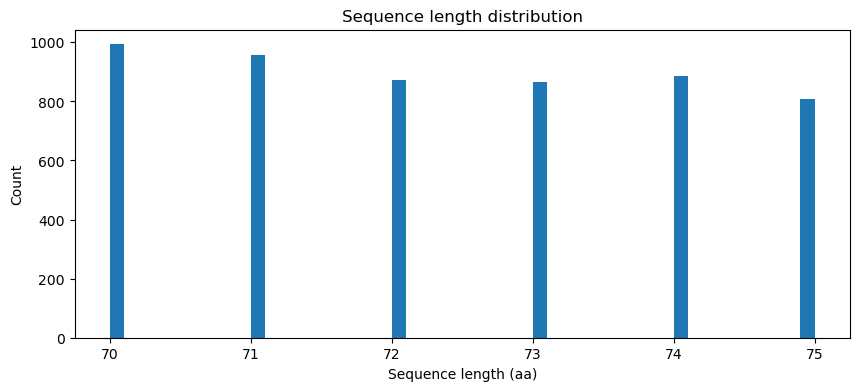

In [19]:
# Sequence length distribution
entries_df["seq_length"].plot.hist(
    bins=50,
    title="Sequence length distribution",
    xlabel="Sequence length (aa)",
    ylabel="Count",
    figsize=(10, 4),
)

<Axes: title={'center': 'Annotation score distribution'}, xlabel='Annotation score', ylabel='Proteins'>

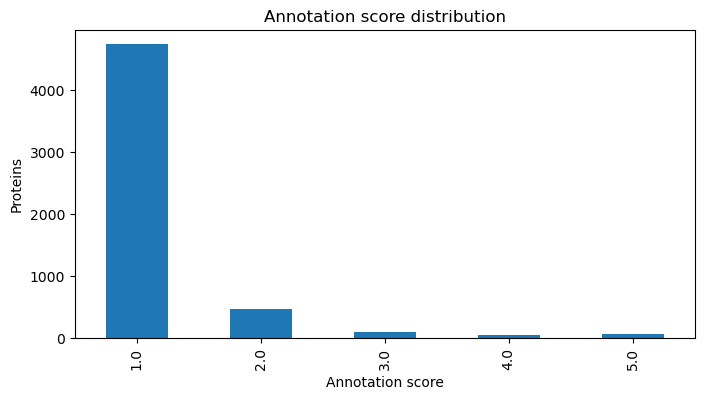

In [20]:
# Annotation score distribution
entries_df["annotation_score"].value_counts().sort_index().plot.bar(
    title="Annotation score distribution",
    xlabel="Annotation score",
    ylabel="Proteins",
    figsize=(8, 4),
)

## 5. PyArrow — file metadata and zero-copy reads

PyArrow gives you low-level access to Parquet metadata (row groups, compression, statistics) without reading the actual data.

In [21]:
import pyarrow.parquet as pq
import pyarrow.dataset as ds

# Inspect the entries Parquet file
entries_file = os.path.join(LAKE, "entries", "entries_00001.parquet")
meta = pq.read_metadata(entries_file)

print(f"Rows:        {meta.num_rows:,}")
print(f"Row groups:  {meta.num_row_groups}")
print(f"Columns:     {meta.num_columns}")
print(f"File size:   {os.path.getsize(entries_file) / 1024 / 1024:.1f} MB")
print(f"Created by:  {meta.created_by}")
print()

# Row group 0 statistics
rg = meta.row_group(0)
print(f"Row group 0: {rg.num_rows:,} rows")
print(f"\nColumn compression (first 10):")
for i in range(min(10, rg.num_columns)):
    col = rg.column(i)
    ratio = col.total_uncompressed_size / max(col.total_compressed_size, 1)
    print(f"  {col.path_in_schema:30s}  {col.compression:6s}  {ratio:.1f}x")

Rows:        5,378
Row groups:  1
Columns:     113
File size:   1.0 MB
Created by:  parquet-cpp-arrow version 23.0.1

Row group 0: 5,378 rows

Column compression (first 10):
  acc                             ZSTD    2.3x
  id                              ZSTD    3.3x
  reviewed                        ZSTD    11.0x
  secondary_accs.list.element     ZSTD    2.1x
  taxid                           ZSTD    1.0x
  organism_name                   ZSTD    1.0x
  organism_common                 ZSTD    0.9x
  lineage.list.element            ZSTD    77.9x
  gene_names.list.element         ZSTD    1.6x
  gene_synonyms.list.element      ZSTD    1.6x


In [22]:
# PyArrow Dataset API — read with filters (pushdown)
entries_ds = ds.dataset(os.path.join(LAKE, "entries"), format="parquet")

# Read the longest proteins (above median length)
median_len = con.sql("SELECT median(seq_length) FROM entries").fetchone()[0]
table = entries_ds.to_table(
    columns=["acc", "protein_name", "seq_length"],
    filter=ds.field("seq_length") > median_len,
)
print(f"{table.num_rows} proteins above median length ({median_len} aa)")
table.to_pandas().head(10)

2558 proteins above median length (72.0 aa)


,acc,protein_name,seq_length
0,A0A178U9T0,Serine rich endogenous peptide 16,74
1,A0JQ18,Serine rich endogenous peptide 14,73
2,O49519,CLAVATA3/ESR (CLE)-related protein 2,75
3,O65919,Protein RALF-like 10,73
4,O82232,PMP3 family protein At2g24040,75
5,O82275,Signaling peptide TAXIMIN 1,75
6,O82337,Arabinogalactan protein 16,73
7,P0CAY1,Putative defensin-like protein 42,73
8,P56780,Photosystem II reaction center protein H,73
9,P82721,Putative defensin-like protein 126,75


## 6. Analytical use cases

These queries demonstrate patterns that are impractical or impossible via UniProt's REST API — cross-proteome aggregations, positional analysis, and compositional profiling.

In [23]:
# Feature density per protein — which proteins are most annotated per amino acid?
con.sql("""
    SELECT
        acc,
        gene_name,
        seq_length,
        feature_count,
        round(feature_count * 1000.0 / seq_length, 1) AS features_per_1k_aa
    FROM entries
    WHERE seq_length > 0
    ORDER BY features_per_1k_aa DESC
    LIMIT 15
""").df()

,acc,gene_name,seq_length,feature_count,features_per_1k_aa
0,Q969W0,SPTSSA,71,15,211.3
1,P22139,RPB10,70,14,200.0
2,P40422,RPC10,70,14,200.0
3,P59768,GNG2,71,14,197.2
4,P22532,SPRR2D,72,14,194.4
5,P38636,ATX1,73,14,191.8
6,P41964,Drs,70,13,185.7
7,Q1RKY8,None,71,13,183.1
8,P56780,psbH,73,13,178.1
9,P63213,Gng2,71,12,169.0


In [24]:
# Sequence composition — find cysteine-rich proteins
con.sql("""
    SELECT
        acc,
        gene_name,
        seq_length,
        length(sequence) - length(replace(sequence, 'C', '')) AS cysteine_count,
        round((length(sequence) - length(replace(sequence, 'C', ''))) * 100.0
              / seq_length, 1) AS cysteine_pct
    FROM entries
    WHERE seq_length > 50
    ORDER BY cysteine_pct DESC
    LIMIT 15
""").df()

,acc,gene_name,seq_length,cysteine_count,cysteine_pct
0,Q01643,Mst84Db,74,27,36.5
1,A0A1B2AK97,None,74,27,36.5
2,Q01645,Mst84Dd,72,25,34.7
3,A0A1B2AL86,None,72,25,34.7
4,A0A024DAF4,ITGB2,72,16,22.2
5,A0A891XJG5,ITGB2,72,16,22.2
6,F1C633,ITGB3,73,16,21.9
7,F1C634,ITGB3,73,16,21.9
8,H3BR34,MT1B,70,14,20.0
9,D4G7F0,None,70,13,18.6


In [25]:
# Feature coverage — what fraction of each protein is annotated?
con.sql("""
    WITH coverage AS (
        SELECT
            f.acc,
            e.gene_name,
            e.seq_length,
            sum(GREATEST(f.end_pos - f.start_pos + 1, 0)) AS annotated_aa
        FROM features f
        JOIN entries e ON e.acc = f.acc
        WHERE f.start_pos IS NOT NULL
          AND f.end_pos IS NOT NULL
          AND f.type NOT IN ('Chain', 'Modified residue')  -- exclude full-length features
        GROUP BY f.acc, e.gene_name, e.seq_length
    )
    SELECT
        acc,
        gene_name,
        seq_length,
        annotated_aa,
        round(annotated_aa * 100.0 / seq_length, 1) AS coverage_pct
    FROM coverage
    WHERE seq_length > 100
    ORDER BY coverage_pct DESC
    LIMIT 15
""").df()

,acc,gene_name,seq_length,annotated_aa,coverage_pct


In [26]:
# GO term enrichment — most common GO annotations
con.sql("""
    SELECT go_id, count(*) AS protein_count
    FROM (
        SELECT acc, unnest(go_ids) AS go_id
        FROM entries
        WHERE go_ids IS NOT NULL AND len(go_ids) > 0
    )
    GROUP BY go_id
    ORDER BY protein_count DESC
    LIMIT 20
""").df()

,go_id,protein_count
0,GO:0016020,406
1,GO:0042612,239
2,GO:0002474,239
3,GO:0098553,238
4,GO:0030670,238
5,GO:0005634,187
6,GO:0005576,141
7,GO:0005737,110
8,GO:0002250,98
9,GO:0042613,95


In [27]:
# Keyword co-occurrence — which keywords appear together most often?
con.sql("""
    WITH kw AS (
        SELECT acc, unnest(keyword_names) AS keyword
        FROM entries
        WHERE keyword_names IS NOT NULL AND len(keyword_names) > 0
    )
    SELECT
        a.keyword AS keyword_1,
        b.keyword AS keyword_2,
        count(*) AS co_occurrences
    FROM kw a
    JOIN kw b ON a.acc = b.acc AND a.keyword < b.keyword
    GROUP BY keyword_1, keyword_2
    ORDER BY co_occurrences DESC
    LIMIT 15
""").df()

,keyword_1,keyword_2,co_occurrences
0,Proteomics identification,Reference proteome,1599
1,Membrane,Transmembrane,762
2,Membrane,Transmembrane helix,741
3,Transmembrane,Transmembrane helix,741
4,Glycoprotein,Signal,699
5,Membrane,Signal,425
6,Membrane,Reference proteome,424
7,Glycoprotein,Membrane,393
8,Reference proteome,Transmembrane,356
9,Reference proteome,Signal,342


In [28]:
# Publication timeline — when were these proteins characterised?
con.sql("""
    SELECT
        publication_date,
        count(*) AS citations
    FROM publications
    WHERE publication_date IS NOT NULL
    GROUP BY publication_date
    ORDER BY publication_date
""").df()

,publication_date,citations
0,0,2
1,1975,1
2,1977,1
3,1979,1
4,1983,3
...,...,...
306,SEP-2013,2
307,SEP-2014,2
308,SEP-2017,2
309,SEP-2020,165


### Unnesting arrays and nested structures

Many columns in the lake are arrays (`VARCHAR[]`, `STRUCT[]`) or JSON. DuckDB's `unnest()` flattens these into rows, `->` extracts JSON fields, and `->>` extracts as text. This section shows common patterns.

In [29]:
# Unnest GO terms — one row per protein × GO ID
# (unnest in SELECT + GROUP BY requires a subquery)
con.sql("""
    SELECT go_id, count(DISTINCT acc) AS protein_count
    FROM (
        SELECT acc, unnest(go_ids) AS go_id
        FROM entries
        WHERE go_ids IS NOT NULL
    )
    GROUP BY go_id
    ORDER BY protein_count DESC
    LIMIT 15
""").df()

,go_id,protein_count
0,GO:0016020,406
1,GO:0042612,239
2,GO:0002474,239
3,GO:0030670,238
4,GO:0098553,238
5,GO:0005634,187
6,GO:0005576,141
7,GO:0005737,110
8,GO:0002250,98
9,GO:0042613,95


In [30]:
# Unnest gene synonyms — find all aliases for each protein
con.sql("""
    SELECT acc, gene_name, unnest(gene_synonyms) AS synonym
    FROM entries
    WHERE gene_synonyms IS NOT NULL AND len(gene_synonyms) > 0
    LIMIT 15
""").df()

,acc,gene_name,synonym
0,A0A178U9T0,PROSCOOP16,SCOOP16
1,A0JQ18,PROSCOOP14,SCOOP14
2,A0JQ18,PROSCOOP14,STMP2
3,Q1G3E7,PROSCOOP23,SCOOP23
4,Q3E8H4,PROSCOOP1,SCOOP1
5,Q570K8,PROSCOOP4,SCOOP4
6,Q570K8,PROSCOOP4,STMP10
7,Q6NNM0,TFB5,GTF2H5
8,Q8GWN6,PROSCOOP8,SCOOP8
9,Q8LFJ6,NRPB10,NRPD10


In [31]:
# Unnest secondary accessions — trace merged/demerged UniProt entries
con.sql("""
    SELECT acc, gene_name, unnest(secondary_accs) AS old_acc
    FROM entries
    WHERE secondary_accs IS NOT NULL AND len(secondary_accs) > 0
    LIMIT 15
""").df()

,acc,gene_name,old_acc
0,A0A178U9T0,PROSCOOP16,A0A1P8BAI7
1,A0A178WF56,CYSTM3,A0A1P8ANL9
2,F4ISE1,RALFL12,O64467
3,O82232,None,Q53XD6
4,P82731,LCR16,A0MJV4
5,P82734,LCR20,Q4VP05
6,P82734,LCR20,Q4VP06
7,Q1G309,TAX2,A0MDZ4
8,Q1G3E7,PROSCOOP23,A0MDW5
9,Q1G3R6,ESFL4,A0MDP9


In [32]:
# Unnest cross-reference properties (struct array) with LATERAL join
# Each PDB xref has Method, Resolution, and Chains properties
con.sql("""
    SELECT x.acc, e.gene_name, x.id AS pdb_id, p.key, p.value
    FROM xrefs x
    JOIN entries e ON e.acc = x.acc,
    LATERAL unnest(x.properties) AS t(p)
    WHERE x.database = 'PDB'
      AND e.annotation_score = 5
    ORDER BY e.gene_name, x.id
    LIMIT 15
""").df()

,acc,gene_name,pdb_id,key,value
0,Q9BS18,ANAPC13,4UI9,Chains,M=1-74
1,Q9BS18,ANAPC13,4UI9,Resolution,3.60 A
2,Q9BS18,ANAPC13,4UI9,Method,EM
3,Q9BS18,ANAPC13,5G04,Method,EM
4,Q9BS18,ANAPC13,5G04,Resolution,4.00 A
5,Q9BS18,ANAPC13,5G04,Chains,M=1-74
6,Q9BS18,ANAPC13,5KHR,Resolution,6.10 A
7,Q9BS18,ANAPC13,5KHR,Chains,M=1-74
8,Q9BS18,ANAPC13,5KHR,Method,EM
9,Q9BS18,ANAPC13,5KHU,Chains,M=1-74


In [33]:
# Unnest isoforms — the unnest_isoforms() macro parses JSON from the comment map
# Find a protein with alternative products (isoforms)
iso_acc = con.sql("""
    SELECT acc FROM comments
    WHERE comment_type = 'ALTERNATIVE PRODUCTS'
    LIMIT 1
""").fetchone()
if iso_acc:
    print(f"Isoforms for {iso_acc[0]}:")
    con.sql(f"SELECT * FROM unnest_isoforms('{iso_acc[0]}')").df()
else:
    print("No entries with alternative products in this dataset")

Isoforms for O82337:


In [34]:
# Proteome-wide isoform census — which proteins have the most splice variants?
# comment column is JSON — use -> to extract fields, from_json to parse into structs
con.sql("""
    WITH iso AS (
        SELECT
            acc,
            unnest(
                from_json(
                    comment->'$.isoforms',
                    '[{"isoformIds":["VARCHAR"]}]'
                )
            ).isoformIds AS ids
        FROM comments
        WHERE comment_type = 'ALTERNATIVE PRODUCTS'
    )
    SELECT i.acc, e.gene_name, len(i.ids) AS n_isoforms
    FROM iso i
    JOIN entries e ON e.acc = i.acc
    ORDER BY n_isoforms DESC
    LIMIT 15
""").df()

,acc,gene_name,n_isoforms
0,O82337,AGP16,1
1,Q4VNZ9,None,1
2,Q9M157,ETC3,1
3,Q9XIR8,DSS1(I),1
4,F7VJQ1,PRNP,1
5,L0R8F8,MIEF1,1
6,P60896,SEM1,1
7,Q75NE6,MIR17HG,1
8,Q8IUB3,WFDC10B,1
9,Q8WUW1,BRK1,1


## 7. Interoperability — zero-copy transfers

DuckDB, Polars, and pandas can exchange data through Apache Arrow with zero copies.

In [35]:
# DuckDB → Polars (zero-copy via Arrow)
arrow_table = con.sql(f"""
    SELECT acc, gene_name, protein_name, seq_length, go_ids
    FROM entries
    WHERE seq_length > {median_len}
    ORDER BY seq_length DESC
""").arrow()

polars_df = pl.from_arrow(arrow_table)
print(f"Zero-copy transfer: {len(polars_df)} rows from DuckDB → Polars")
polars_df.head()

Zero-copy transfer: 2558 rows from DuckDB → Polars


acc,gene_name,protein_name,seq_length,go_ids
str,str,str,i32,list[str]
"""O49519""","""CLE2""","""CLAVATA3/ESR (CLE)-related pro…",75,"[""GO:0045165"", ""GO:0007267"", … ""GO:0048046""]"
"""O82232""",null,"""PMP3 family protein At2g24040""",75,"[""GO:0016020""]"
"""O82275""","""TAX1""","""Signaling peptide TAXIMIN 1""",75,"[""GO:0009416"", ""GO:0010199"", … ""GO:0005615""]"
"""P82721""","""LCR6""","""Putative defensin-like protein…",75,"[""GO:0031640"", ""GO:0050832"", ""GO:0005576""]"
"""P82734""","""LCR20""","""Defensin-like protein 127""",75,"[""GO:0031640"", ""GO:0050832"", ""GO:0005576""]"


In [36]:
# DuckDB → pandas
pandas_df = con.sql("""
    SELECT acc, gene_name, seq_length, feature_count
    FROM entries
    ORDER BY feature_count DESC
    LIMIT 20
""").df()

pandas_df

,acc,gene_name,seq_length,feature_count
0,Q969W0,SPTSSA,71,15
1,P22532,SPRR2D,72,14
2,P59768,GNG2,71,14
3,P22139,RPB10,70,14
4,P38636,ATX1,73,14
5,P40422,RPC10,70,14
6,P56780,psbH,73,13
7,P41964,Drs,70,13
8,Q1RKY8,None,71,13
9,Q96B49,TOMM6,74,12


In [37]:
# Export to CSV via DuckDB
csv_path = os.path.join(os.getcwd(), "lake_kinases.csv")
con.sql(f"""
    COPY (
        SELECT acc, gene_name, protein_name, seq_length, ec_numbers
        FROM entries
        WHERE list_contains(keyword_names, 'Kinase')
        ORDER BY gene_name
    ) TO '{csv_path}' (HEADER, DELIMITER ',')
""")

# Verify
result = pd.read_csv(csv_path)
print(f"Exported {len(result)} kinases to {csv_path}")
result.head(10)

Exported 43 kinases to /Users/dlrice/Developer/uniprot-parquet/demo/lake_kinases.csv


,acc,gene_name,protein_name,seq_length,ec_numbers
0,F7BP55,Ak2,NaN,72,[]
1,Q3MS90,BTK,NaN,74,[]
2,F8VYY1,CDK4,cyclin-dependent kinase,74,[2.7.11.22]
3,H3BRW2,CLK3,dual-specificity kinase,70,[2.7.12.1]
4,A0A2R8Y3W6,CSNK2A1,non-specific serine/threonine protein kinase,74,[2.7.11.1]
5,A0A1Y7VKB8,Cdk20,Cyclin-dependent kinase 20,71,[2.7.11.22]
6,D6RHS5,Cdk4,cyclin-dependent kinase,74,[2.7.11.22]
7,G3UX84,Chek1,non-specific serine/threonine protein kinase,74,[2.7.11.1]
8,Q9H3D0,EGFR,receptor protein-tyrosine kinase,70,[2.7.10.1]
9,Q62128,Ephb4,NaN,74,[]


## 8. Accessing nested structures

Every table preserves the full original UniProtKB JSON as nested DuckDB structs. This means no data is ever discarded — if the convenience columns aren't enough, you can always reach into the nested structures.

In [38]:
# Access the full nested organism struct
con.sql("""
    SELECT
        acc,
        organism.scientificName AS scientific_name,
        organism.commonName AS common_name,
        organism.taxonId AS taxon_id,
        organism.lineage AS lineage
    FROM entries
    LIMIT 3
""").df()

,acc,scientific_name,common_name,taxon_id,lineage
0,A0A178U9T0,Arabidopsis thaliana,Mouse-ear cress,3702,"[Eukaryota, Viridiplantae, Streptophyta, Embry..."
1,A0A178WF56,Arabidopsis thaliana,Mouse-ear cress,3702,"[Eukaryota, Viridiplantae, Streptophyta, Embry..."
2,A0JQ18,Arabidopsis thaliana,Mouse-ear cress,3702,"[Eukaryota, Viridiplantae, Streptophyta, Embry..."


In [39]:
# Access the full nested feature struct (includes evidence codes, cross-references)
# Pick the entry with the most features
feat_acc = con.sql("""
    SELECT acc FROM entries
    WHERE reviewed = true
    ORDER BY feature_count DESC LIMIT 1
""").fetchone()[0]
print(f"Features for {feat_acc}:")
con.sql(f"""
    SELECT
        acc,
        feature.type AS type,
        feature.description AS description,
        feature.location.start.value AS start_pos,
        feature.location.end.value AS end_pos,
        feature.evidences AS evidences
    FROM features
    WHERE acc = '{feat_acc}'
    LIMIT 10
""").df()

Features for Q969W0:


,acc,type,description,start_pos,end_pos,evidences
0,Q969W0,Chain,Serine palmitoyltransferase small subunit A,1,71,<NA>
1,Q969W0,Topological domain,Cytoplasmic,1,12,"[{'evidenceCode': 'ECO:0000255', 'source': Non..."
2,Q969W0,Transmembrane,Helical,13,29,"[{'evidenceCode': 'ECO:0000255', 'source': Non..."
3,Q969W0,Topological domain,Lumenal,30,34,"[{'evidenceCode': 'ECO:0000255', 'source': Non..."
4,Q969W0,Transmembrane,Helical,35,57,"[{'evidenceCode': 'ECO:0000255', 'source': Non..."
5,Q969W0,Topological domain,Cytoplasmic,58,71,"[{'evidenceCode': 'ECO:0000255', 'source': Non..."
6,Q969W0,Site,Within the serine palmitoyltransferase (SPT) c...,28,28,<NA>
7,Q969W0,Natural variant,in SPG90A; likely pathogenic; results in incre...,51,51,"[{'evidenceCode': 'ECO:0000269', 'source': 'Pu..."
8,Q969W0,Mutagenesis,Within the serine palmitoyltransferase (SPT) c...,28,28,"[{'evidenceCode': 'ECO:0000269', 'source': 'Pu..."
9,Q969W0,Mutagenesis,Impaired down-regulation of SPT complex activi...,59,59,"[{'evidenceCode': 'ECO:0000269', 'source': 'Pu..."


In [40]:
# Access the full nested comment JSON (polymorphic — varies by comment type)
# comment is JSON — use ->> to extract text values, -> for nested objects
# Reuse the same well-annotated protein
print(f"Comments for {feat_acc}:")
con.sql(f"""
    SELECT
        acc,
        comment_type,
        comment->>'$.texts[0].value'                             AS text,
        comment->>'$.subcellularLocations[0].location.value'     AS location,
        comment->>'$.reaction.name'                              AS reaction
    FROM comments
    WHERE acc = '{feat_acc}'
""").df()

Comments for Q969W0:


,acc,comment_type,text,location,reaction
0,Q969W0,FUNCTION,Component of the serine palmitoyltransferase m...,None,None
1,Q969W0,PATHWAY,Lipid metabolism; sphingolipid metabolism,None,None
2,Q969W0,SUBUNIT,Component of the serine palmitoyltransferase (...,None,None
3,Q969W0,INTERACTION,None,None,None
4,Q969W0,SUBCELLULAR LOCATION,None,Endoplasmic reticulum membrane,None
5,Q969W0,DISEASE,None,None,None
6,Q969W0,DISEASE,None,None,None
7,Q969W0,SIMILARITY,Belongs to the SPTSS family. SPTSSA subfamily,None,None
8,Q969W0,CAUTION,It is uncertain whether Met-1 or Met-4 is the ...,None,None
9,Q969W0,SEQUENCE CAUTION,None,None,None
